In [ ]:
import pandas as pd
import json
import numpy as np
import requests
from tqdm.auto import tqdm
from config import URL, TOKEN


import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [ ]:
headers = {
    "Authorization": f"Bearer {TOKEN}"
}

itemCount = np.inf
data = {"entries": []}

offset = 0
steps = 1000

progress = None

while len(data["entries"]) < itemCount:

    response = requests.get(
        f"{URL}person/caregiver/query?filter=section.eingestellt-am:answerDateTime.timeUtc:gte:20170101000000,section.eingestellt-am:answerDateTime.timeUtc:lt:20260101000000&limit={steps}&skip={offset}",
        headers=headers,
        verify=False
    )

    if response.status_code == 200:
        responseData = response.json()

        entries = responseData["entries"]

        # Total becomes known after first request
        if progress is None:
            itemCount = responseData["pagingInfo"]["itemCount"]

            progress = tqdm(
                total=itemCount,
                desc="Downloading caregivers",
                unit="entries"                
            )

        data["entries"].extend(entries)

        # Advance by actual number received
        progress.update(len(entries))

        offset += steps

    else:
        print(response.json())
        break

if progress is not None:
    progress.close()

In [7]:
exceptions = [
	"metadata",
	"locality",
	"postalcode",
	"contactoptions",
	"personFullName",
	"personFullNameNoTitle",
	"tenantid",
	"persontype",
	"adresse",
	"mailAddressing",
	"socialInsuranceNumber",
	"comments",
	"givenName",
	"familyName",
	"primaryEmailAddress",
	'addresses',
	'primaryPhoneNumber',
	'address',
	'residentialAddress',
	'address',
	'geoLocation',
	'billingAddress',
	'serviceAddress',
	'legalAddress',
	'businessAddress',
	'emailAddresses',
	'phoneNumbers',
	'personFullNameNoTitle',
	'personFullName',
	'mailAddressing',
	'postalAddress',
	'contractualAddressing',
	'caatsDateOfBirth',
	'gender',
	'locations',
	'bankDetails',
	'personStatus',
	"chapterId",
	"language",
	"ordinal",
	"sectionId",
	"academicTitlePrefix",
	"personNr",
	"content",
	"consecutiveNumber",
	'Klient:innen_Empfohlen_Ja',
	'Klient:innen_Erstrkontakt_erfassen_Ja',
	'Klient:innen_Bew_Ein_Ja',
	'abrech-akonto',
	'abrech-buerge-hinterlegt',
	'pers-visite-keine',
	'medizinische-delegation-hochgeladen',
	'medizinische-delegation-nicht-notwendig',
	'Klient:innen_Medizinische_Delegation_Ja',
	'pflegerische-delegation-hochgeladen',
	'pflegerische-delegation-nicht-notwendig',
	'Klient:innen_Pflegerische_Delegation_JA',
	"admin-beruf",
	'pflegevisite-letzte-date',
	'pflegevisite-letzte-dgkp',
	'pflegerisch-person',
	'erstkontakt-bemerkung',
	"admin-kooperationspartner",
	'birthName',
'confessionId',
'confession',
'nationalityId',
'placeOfBirth',
'paymentBlockReason',
'chamberOfCommerceMembershipNr',
'avatarFileId',
'empfohlen-von-category',
'visibilityConditionId',
'deutschkennt-bew-von',
'Kinder_Nein',
'covid-1',
'covid-2',
'covid-3',
'keine-kurse',
'agentur-zuletzt',

]

exceptions = [x.lower() for x in exceptions]

In [8]:
def extractStatement(statement):
    field = {}
    if statement["statementId"].lower() in exceptions:
        return field

    match statement["answerScheme"]:
        case 1:
            field[statement["statementId"]] = statement["answerValue"]["displayText"]
        case 2:
            #do nothing
            field = {}
        case 3:
            field[statement["statementId"]] = statement["answerYesno"] == 2
        case 4:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False

        case 5:
            answers = statement["answers"]
            for answer in answers:
                if "isSelected" in answer.keys():
                    field[answer["answerId"]] = answer["isSelected"]
                else:
                    field[answer["answerId"]] = False
        case 8:
            if "answerDateTime" in statement.keys():
                if "userLocalTime" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["userLocalTime"]
                elif "timeUtc" in statement["answerDateTime"].keys():
                    field[statement["statementId"]] = statement["answerDateTime"]["timeUtc"]
        case _:
            print(f'Found statement: {statement["answerScheme"]} - {statement["statementId"]} -  {statement}')


    return field
        

def returnEntry(entry):
    keys = entry.keys()
    finalFields = {}
    if "statementId" in keys:
        finalFields = finalFields | extractStatement(entry)
    else:
        for key in keys:
            
            if key.lower() in exceptions:
                continue
            
            typing = type(entry[key]).__name__
            match typing:
                case "str":
                    finalFields[key] = entry[key]
                    
                case "int":
                    finalFields[key] = entry[key]

                case "bool":
                    finalFields[key] = entry[key]

                case "float":
                    finalFields[key] = entry[key]
                    
                case "dict":
                    if "displayText" in entry[key].keys():
                        finalFields[key] = entry[key]["displayText"]
                        continue
                    else:
                        finalFields = finalFields | returnEntry(entry[key])
                    
                case "list":
                    for item in entry[key]:
                        if type(item).__name__ == "dict":
                            finalFields = finalFields | returnEntry(item)
                        

                case _:
                    print(typing)


    
    return finalFields

In [9]:

totalData = []

if data["entries"] is not None:
    for entry in data["entries"]:
        test = returnEntry(entry)
        totalData.append(test)
        
df = pd.DataFrame(totalData)
df

,genderId,id,orgRef,dateOfBirth,nationality,maritalStatus,preferredCycleLength,preferredTransport,Betreuer:innen_Bew_Ein_Ja,bew-am,...,pers-dat-sprach-weit2,schulische-ausbildung-info,weitere_ausbildungen,ausbildung-krankenschwester-info,ausbildung-krankenschwester-ausbildungsstaette,BE_REISEPASS,BE_REISEPASS_NR,BE_REISEPASS_BEHOERDE,BE_REISEPASS_GUELTIG_AB,BE_REISEPASS_GUELTIG_BIS
0,F,000e3dec-c8ed-0c9c-c923-22248a6482bc,Team Ungarn,19690927,Rumänien,Verheiratet,28,Sonstiges,False,2.023052e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F,0023180d-aea5-2937-a175-883bf09769ec,Sonstiges,19950829,Rumänien,NaN,28,Selbstfahrer,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,Direktbewerbung,19950804,Rumänien,Verheiratet,NaN,Sonstiges,False,2.019071e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F,00273d77-cdb2-65da-1d2d-47770f9d5b8b,Team Rumänien,19680518,Rumänien,Geschieden,28,Blagoiescu,False,2.022100e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F,002e16cc-274f-bf74-d123-98b4704b1aab,Team Rumänien,19810731,Rumänien,Verheiratet,28,Blagoiescu,False,2.025013e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15113,F,ffeeed61-12e9-240f-9a76-e41d17658338,Sonstiges,19520922,Rumänien,NaN,NaN,Selbstfahrer,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15114,F,fff6676f-b4fa-468a-ac4c-644c7dbcebe1,Team Rumänien,19951006,Rumänien,Ledig,28,Blagoiescu,False,2.025013e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15115,F,fff69680-3c80-f8d0-72dc-ba008ca86386,Team Ungarn,19670727,Ungarn,Verheiratet,NaN,Master Express,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15116,F,fffb765b-811b-4eae-0ff2-ab6e3859ba60,ZZ_Rodlauer Übernahme,19670822,Rumänien,Verheiratet,28,Blagoiescu,False,2.023012e+13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
for col in df.columns:
    non_null = df[col].dropna()

    if len(non_null) > 0 and non_null.isin([True, False]).all():
        df[col] = df[col].fillna(False).astype(bool)

bool_cols = df.select_dtypes(include=["bool", "boolean"]).columns

df[bool_cols] = df[bool_cols].fillna(False)


df = df.replace(r'^\s*$', np.nan, regex=True)

df

C:\Users\npozdena\AppData\Local\Temp\ipykernel_17152\826111804.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(bool)
C:\Users\npozdena\AppData\Local\Temp\ipykernel_17152\826111804.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(bool)
C:\Users\npozdena\AppData\Local\Temp\ipykernel_17152\826111804.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead.

,genderId,id,orgRef,dateOfBirth,nationality,maritalStatus,preferredCycleLength,preferredTransport,Betreuer:innen_Bew_Ein_Ja,bew-am,...,pers-dat-sprach-weit2,schulische-ausbildung-info,weitere_ausbildungen,ausbildung-krankenschwester-info,ausbildung-krankenschwester-ausbildungsstaette,BE_REISEPASS,BE_REISEPASS_NR,BE_REISEPASS_BEHOERDE,BE_REISEPASS_GUELTIG_AB,BE_REISEPASS_GUELTIG_BIS
0,F,000e3dec-c8ed-0c9c-c923-22248a6482bc,Team Ungarn,19690927,Rumänien,Verheiratet,28,Sonstiges,False,2.023052e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
1,F,0023180d-aea5-2937-a175-883bf09769ec,Sonstiges,19950829,Rumänien,NaN,28,Selbstfahrer,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
2,F,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,Direktbewerbung,19950804,Rumänien,Verheiratet,NaN,Sonstiges,False,2.019071e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
3,F,00273d77-cdb2-65da-1d2d-47770f9d5b8b,Team Rumänien,19680518,Rumänien,Geschieden,28,Blagoiescu,False,2.022100e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
4,F,002e16cc-274f-bf74-d123-98b4704b1aab,Team Rumänien,19810731,Rumänien,Verheiratet,28,Blagoiescu,False,2.025013e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15113,F,ffeeed61-12e9-240f-9a76-e41d17658338,Sonstiges,19520922,Rumänien,NaN,NaN,Selbstfahrer,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
15114,F,fff6676f-b4fa-468a-ac4c-644c7dbcebe1,Team Rumänien,19951006,Rumänien,Ledig,28,Blagoiescu,False,2.025013e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
15115,F,fff69680-3c80-f8d0-72dc-ba008ca86386,Team Ungarn,19670727,Ungarn,Verheiratet,NaN,Master Express,False,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN
15116,F,fffb765b-811b-4eae-0ff2-ab6e3859ba60,ZZ_Rodlauer Übernahme,19670822,Rumänien,Verheiratet,28,Blagoiescu,False,2.023012e+13,...,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN


In [11]:
df.isna().sum()[df.isna().sum() > 0]

dateOfBirth                                          19
nationality                                          71
maritalStatus                                      6725
preferredCycleLength                               5708
preferredTransport                                 2308
                                                  ...  
ausbildung-krankenschwester-ausbildungsstaette    15109
BE_REISEPASS_NR                                   15097
BE_REISEPASS_BEHOERDE                             15101
BE_REISEPASS_GUELTIG_AB                           15097
BE_REISEPASS_GUELTIG_BIS                          15097
Length: 78, dtype: int64

In [12]:
protected_cols = ["eingestellt-am", "id", "ausgesch-am"]

# All normal feature columns
feature_cols = df.columns.drop(protected_cols)

# Keep only feature columns with <= 10% missing
keep_features = feature_cols[
    df[feature_cols].isna().mean() <= 0.10
]

# Keep protected columns + surviving features
df = df[protected_cols + keep_features.tolist()]

# Drop rows with missing values in:
# - eingestellt-am
# - id
# - any remaining feature
#
# ausgesch-am is intentionally excluded
required_cols = ["eingestellt-am", "id"] + keep_features.tolist()

df = df.dropna(subset=required_cols)

In [13]:
df

,eingestellt-am,id,ausgesch-am,genderId,orgRef,dateOfBirth,nationality,Betreuer:innen_Bew_Ein_Ja,istangest,macht-stundenpak,...,PFKompAllgemein,arrivalSelfOrganized,departureSelfOrganized,arrivalNoBilling,departureNoBilling,Gewerbe_ruhend_Ja,Betreuer:innen_Austritt_Ja,e-zigarette,isPaymentBlocked,BE_REISEPASS
2,2.019090e+13,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,2.025042e+13,F,Direktbewerbung,19950804,Rumänien,False,True,False,...,0,False,False,False,False,False,False,False,False,False
5,2.026040e+13,0033cdc8-5cf7-4b86-7aab-8068d11dae31,NaN,F,Regenbogen Übernahme,19660712,Rumänien,False,True,True,...,0,True,True,True,True,False,False,False,False,False
6,2.015052e+13,00390a58-ce9f-cad0-49c3-2ffdd1d1f741,2.016112e+13,F,Sonstiges,19760531,Rumänien,False,True,True,...,0,False,False,False,False,False,False,False,False,False
8,2.013022e+13,003f8558-4113-01c8-6489-24e702d243bf,2.014020e+13,F,Sonstiges,19690105,Rumänien,False,True,True,...,0,False,False,False,False,False,False,False,False,False
9,2.025102e+13,00411252-62ff-bc52-5ab0-5fbfd476b2a2,2.025111e+13,F,Team Rumänien,19710127,Rumänien,False,True,True,...,0.5,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15108,2.018102e+13,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,2.025111e+13,F,Direktbewerbung,19640207,Rumänien,False,True,False,...,1.26,False,False,False,False,False,False,False,False,False
15111,2.026043e+13,ffe6b973-a479-05e5-a452-711db5f28fef,NaN,F,Pflege aktiv 24,19930820,Rumänien,False,True,True,...,0,True,True,True,True,False,False,False,False,False
15112,2.015061e+13,ffe7facc-ff13-815c-91e6-4c59b007c897,2.015062e+13,F,Sonstiges,19590919,Rumänien,False,True,True,...,0,False,False,False,False,False,False,False,False,False
15115,2.015033e+13,fff69680-3c80-f8d0-72dc-ba008ca86386,NaN,F,Team Ungarn,19670727,Ungarn,False,True,True,...,1.33333333333333,False,False,False,False,False,False,False,False,False


In [14]:
min_unique = 2
max_unique = len(df) * 0.9


n_unique = df.nunique()

cols_to_drop = n_unique[
    (n_unique < min_unique) | (n_unique > max_unique)
].index

cols_to_drop = [col for col in cols_to_drop if col not in ["id", "ausgesch-am", "eingestellt-am"]]

df = df.drop(columns=cols_to_drop)

df

,eingestellt-am,id,ausgesch-am,genderId,orgRef,dateOfBirth,nationality,istangest,macht-stundenpak,unpassend,...,PFKompHaushalt,PFKompBetreuung,PFKompEmotional,PFKompAllgemein,arrivalSelfOrganized,departureSelfOrganized,arrivalNoBilling,departureNoBilling,Betreuer:innen_Austritt_Ja,isPaymentBlocked
2,2.019090e+13,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,2.025042e+13,F,Direktbewerbung,19950804,Rumänien,True,False,True,...,0,0,0,0,False,False,False,False,False,False
5,2.026040e+13,0033cdc8-5cf7-4b86-7aab-8068d11dae31,NaN,F,Regenbogen Übernahme,19660712,Rumänien,True,True,True,...,0,0,0,0,True,True,True,True,False,False
6,2.015052e+13,00390a58-ce9f-cad0-49c3-2ffdd1d1f741,2.016112e+13,F,Sonstiges,19760531,Rumänien,True,True,True,...,0,0,0,0,False,False,False,False,False,False
8,2.013022e+13,003f8558-4113-01c8-6489-24e702d243bf,2.014020e+13,F,Sonstiges,19690105,Rumänien,True,True,True,...,0,0,0,0,False,False,False,False,False,False
9,2.025102e+13,00411252-62ff-bc52-5ab0-5fbfd476b2a2,2.025111e+13,F,Team Rumänien,19710127,Rumänien,True,True,True,...,1,0.5,0.5,0.5,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15108,2.018102e+13,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,2.025111e+13,F,Direktbewerbung,19640207,Rumänien,True,False,True,...,1.17,1.17,1.22,1.26,False,False,False,False,False,False
15111,2.026043e+13,ffe6b973-a479-05e5-a452-711db5f28fef,NaN,F,Pflege aktiv 24,19930820,Rumänien,True,True,True,...,0,0,0,0,True,True,True,True,False,False
15112,2.015061e+13,ffe7facc-ff13-815c-91e6-4c59b007c897,2.015062e+13,F,Sonstiges,19590919,Rumänien,True,True,True,...,0,0,0,0,False,False,False,False,False,False
15115,2.015033e+13,fff69680-3c80-f8d0-72dc-ba008ca86386,NaN,F,Team Ungarn,19670727,Ungarn,True,True,True,...,1.16666666666667,1.16666666666667,1.08333333333333,1.33333333333333,False,False,False,False,False,False


In [15]:
if "genderId" in df.columns:
    df = pd.get_dummies(df, columns=["genderId"], prefix="gender", drop_first=True)
if "orgRef" in df.columns:
    df = pd.get_dummies(df, columns=["orgRef"], prefix="org", drop_first=True)
if "nationality" in df.columns:
    df = pd.get_dummies(df, columns=["nationality"], prefix="nationality", drop_first=True)
if "preferredTransport" in df.columns:
    df = pd.get_dummies(df, columns=["preferredTransport"], prefix="preferredTransport", drop_first=True)
if "pers-dat-sprach-mutt" in df.columns:
    df = pd.get_dummies(df, columns=["pers-dat-sprach-mutt"], prefix="mutSprach", drop_first=True)
if "admin-betr-gsber" in df.columns:
    df = pd.get_dummies(df, columns=["admin-betr-gsber"], prefix="geschBereich", drop_first=True)

if "PFKompSprache" in df.columns:
	df["PFKompSprache"] = df["PFKompSprache"].astype(float).round(0).astype(int)
if "PFKompHaushalt" in df.columns:
	df["PFKompHaushalt"] = df["PFKompHaushalt"].astype(float).round(0).astype(int)
if "PFKompBetreuung" in df.columns:
	df["PFKompBetreuung"] = df["PFKompBetreuung"].astype(float).round(0).astype(int)
if "PFKompEmotional" in df.columns:
	df["PFKompEmotional"] = df["PFKompEmotional"].astype(float).round(0).astype(int)
if "PFKompAllgemein" in df.columns:
	df["PFKompAllgemein"] = df["PFKompAllgemein"].astype(float).round(0).astype(int)
if "eingestellt-am" in df.columns:
	df["eingestellt-am"] = df["eingestellt-am"].astype(str).str[:8].astype(float)
if "ausgesch-am" in df.columns:
	df["ausgesch-am"] = df["ausgesch-am"].astype(str).str[:8].astype(float)
if "pers-koerper-gewicht" in df.columns:
	df["pers-koerper-gewicht"] = df["pers-koerper-gewicht"].astype(float).round(0).astype(int)
if "pers-koerper-groesse" in df.columns:
	df["pers-koerper-groesse"] = df["pers-koerper-groesse"].astype(float).round(0).astype(int)

In [22]:
cols = df.columns.drop(
    ["id", "ausgesch-am", "eingestellt-am"]
)

numeric = df[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# Keep only rows where all columns converted successfully
df = df[numeric.notna().all(axis=1)].copy()

# Convert to int
df[cols] = df[cols].astype(int)

In [23]:
df

,eingestellt-am,id,ausgesch-am,dateOfBirth,istangest,macht-stundenpak,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,BE_PERSONALAUSWEIS,...,nationality_Slowakei,nationality_Slowenien,nationality_Tschechische Republik,nationality_Ukraine,nationality_Ungarn,nationality_Österreich,geschBereich_Geschäftsbereich H24,geschBereich_Geschäftsbereich PML,geschBereich_Geschäftsbereich SC,geschBereich_Geschäftsbereich SEN
2,20190903.0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,20250423.0,19950804,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,20260401.0,0033cdc8-5cf7-4b86-7aab-8068d11dae31,NaN,19660712,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,20150520.0,00390a58-ce9f-cad0-49c3-2ffdd1d1f741,20161117.0,19760531,1,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,20130220.0,003f8558-4113-01c8-6489-24e702d243bf,20140201.0,19690105,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
9,20251016.0,00411252-62ff-bc52-5ab0-5fbfd476b2a2,20251113.0,19710127,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15108,20181023.0,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,20251106.0,19640207,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
15111,20260428.0,ffe6b973-a479-05e5-a452-711db5f28fef,NaN,19930820,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
15112,20150611.0,ffe7facc-ff13-815c-91e6-4c59b007c897,20150619.0,19590919,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
15115,20150326.0,fff69680-3c80-f8d0-72dc-ba008ca86386,NaN,19670727,1,1,1,0,1,0,...,0,0,0,0,1,0,0,0,0,0


In [24]:
correlation_matrix = df.drop(columns=["id", "ausgesch-am", "eingestellt-am"]).corr()

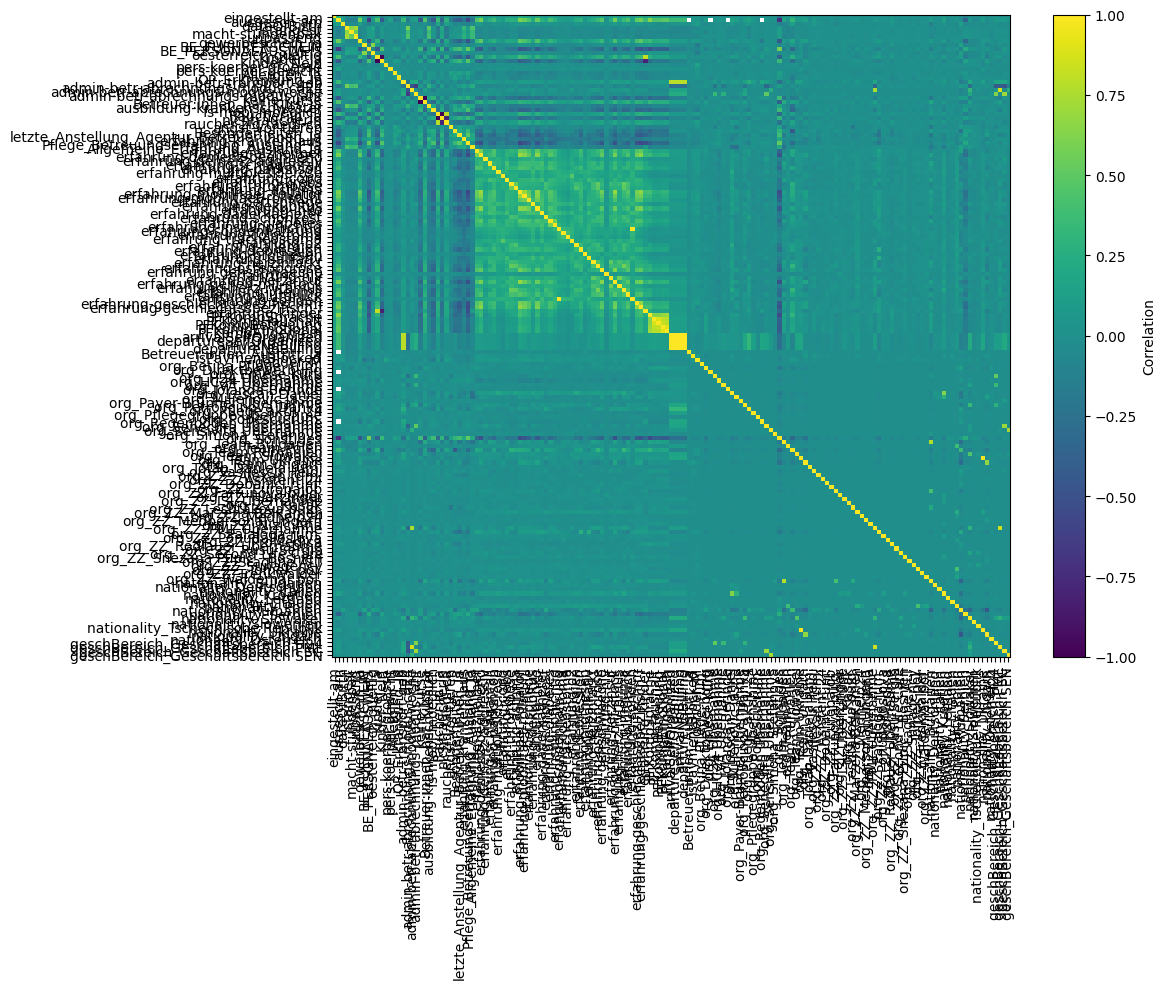

In [25]:
import matplotlib.pyplot as plt

corr = df.drop(columns=["id"]).corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

In [26]:
def remove_correlated_features(df, threshold=0.8, exclude=["id"]):

    result = df.copy()
    dropped = []

    while True:

        features = result.drop(
            columns=exclude,
            errors="ignore"
        )

        corr = features.corr().abs()

        # Remove diagonal
        np.fill_diagonal(corr.values, 0)

        # Find strongest remaining correlation
        max_corr = corr.max().max()

        if max_corr <= threshold:
            break

        # Find the pair
        var1, var2 = corr.stack().idxmax()

        # Mean absolute correlation with all other variables
        score1 = corr.loc[var1].mean()
        score2 = corr.loc[var2].mean()

        # Drop the more redundant variable
        if score1 > score2:
            drop = var1
        else:
            drop = var2

        dropped.append({
            "dropped": drop,
            "var1": var1,
            "var2": var2,
            "pair_corr": max_corr,
            "score_var1": score1,
            "score_var2": score2
        })

        result = result.drop(columns=drop)

    return result, pd.DataFrame(dropped)

In [28]:
df_reduced, dropped = remove_correlated_features(
    df,
    threshold=0.7,
    exclude=["id", "ausgesch-am", "eingestellt-am"]
)

print(dropped)

                               dropped                                var1  \
0                          Kinder_Nein                           Kinder_Ja   
1                        Raucher:in_Ja                       Raucher:in_Ja   
2                     erfahrung-sonden             erfahrung-sondennahrung   
3               departureSelfOrganized                arrivalSelfOrganized   
4                     arrivalNoBilling                arrivalSelfOrganized   
5                   departureNoBilling                arrivalSelfOrganized   
6           Betreuer:innen_hat_Kurs_Ja                         keine-kurse   
7                  nationality_Ukraine                    org_Team Ukraine   
8                      PFKompAllgemein                     PFKompEmotional   
9                      PFKompBetreuung                      PFKompHaushalt   
10  admin-betr-abrechnungs-modus-woche  admin-betr-abrechnungs-modus-woche   
11                org_ZZ_PML Übernahme                org_ZZ_PML

In [29]:
df_reduced

,eingestellt-am,id,ausgesch-am,dateOfBirth,macht-stundenpak,unpassend,gewerbeschein_ja,BE_FUEHRERSCHEIN,BE_PERSONALAUSWEIS,oesterreich-gueltig,...,nationality_Polen,nationality_Rumänien,nationality_Serbien,nationality_Slowakei,nationality_Slowenien,nationality_Tschechische Republik,nationality_Ungarn,nationality_Österreich,geschBereich_Geschäftsbereich H24,geschBereich_Geschäftsbereich PML
2,20190903.0,0025880b-0a6f-d8f3-11f5-87bfa1a5c8f3,20250423.0,19950804,0,1,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
5,20260401.0,0033cdc8-5cf7-4b86-7aab-8068d11dae31,NaN,19660712,1,1,0,1,0,1,...,0,1,0,0,0,0,0,0,0,0
6,20150520.0,00390a58-ce9f-cad0-49c3-2ffdd1d1f741,20161117.0,19760531,1,1,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
8,20130220.0,003f8558-4113-01c8-6489-24e702d243bf,20140201.0,19690105,1,1,0,1,1,1,...,0,1,0,0,0,0,0,0,0,0
9,20251016.0,00411252-62ff-bc52-5ab0-5fbfd476b2a2,20251113.0,19710127,1,1,1,1,0,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15108,20181023.0,ffe2b7bb-9ce9-67a2-76d5-b8116468552d,20251106.0,19640207,0,1,1,0,0,1,...,0,1,0,0,0,0,0,0,0,0
15111,20260428.0,ffe6b973-a479-05e5-a452-711db5f28fef,NaN,19930820,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
15112,20150611.0,ffe7facc-ff13-815c-91e6-4c59b007c897,20150619.0,19590919,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
15115,20150326.0,fff69680-3c80-f8d0-72dc-ba008ca86386,NaN,19670727,1,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0


In [30]:
df_reduced.to_csv("caregivers.csv", sep=";", index=False)